# Notebook 03 : essais de modèles avec tracking MLflow

**Projet** : Laplace Immo, simulateur d'estimation de prix de maisons  
**Auteurs** : Astou DIALLO, Oumane SALL (EPT, DIC3)  
**Date** : juin 2026

## Objectif

Tester systématiquement plusieurs modèles de régression sur le dataset Ames pour identifier le meilleur candidat. Chaque essai est tracké dans **MLflow** avec ses paramètres, ses métriques et son modèle sérialisé.

Modèles testés (10+) :

1. `LinearRegression` (baseline)
2. `Ridge` (deux alphas)
3. `Lasso` (deux alphas)
4. `ElasticNet`
5. `RandomForestRegressor`
6. `GradientBoostingRegressor`
7. `XGBRegressor`
8. `LGBMRegressor`
9. `CatBoostRegressor`

## Plan

1. Setup (imports, configuration MLflow)
2. Préparation des données (load + clean + features + split + log1p)
3. Fonction d'évaluation (helper qui factorise le pattern "fit + CV + test + log MLflow")
4. Modèles linéaires : `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`
5. Modèles à base d'arbres : `RandomForest`, `GradientBoosting`
6. Boosting avancé : `XGBoost`, `LightGBM`, `CatBoost`
7. Synthèse comparative + visualisation
8. Sélection du modèle final

## 1. Setup

On configure MLflow pour un tracking local : les expériences seront stockées dans le dossier `mlruns/` à la racine du projet. Pour visualiser les runs, lancer en parallèle dans un terminal :

```bash
mlflow ui
```

Puis ouvrir http://localhost:5000 dans le navigateur.

In [1]:
# Imports standards
import sys
import time
import warnings
from pathlib import Path

# Racine du projet dans sys.path pour importer src/
chemin_projet = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(chemin_projet) not in sys.path:
    sys.path.insert(0, str(chemin_projet))

# Imports tiers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Imports locaux
from src.data import charger_donnees, NOM_CIBLE
from src.preprocessing import nettoyer_donnees
from src.features import creer_features
from src.pipeline import construire_pipeline

# Reduction du bruit dans la console
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Configuration affichage
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print(f"Racine projet : {chemin_projet}")

Racine projet : c:\Users\HP\Desktop\DIC3\MLOPS\projet_mlops


In [2]:
# Configuration de MLflow : tracking local dans le dossier mlruns/
mlflow.set_tracking_uri(f"file:{chemin_projet / 'mlruns'}")
EXPERIMENT_NAME = "laplace_immo_essais"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment    : {EXPERIMENT_NAME}")

2026/06/07 17:18:12 INFO mlflow.tracking.fluent: Experiment with name 'laplace_immo_essais' does not exist. Creating a new experiment.


Tracking URI : file:c:\Users\HP\Desktop\DIC3\MLOPS\projet_mlops\mlruns
Experiment    : laplace_immo_essais


## 2. Préparation des données

On enchaîne les modules construits précédemment : `charger_donnees → nettoyer_donnees → creer_features`. La cible est transformée en `log1p(SalePrice)` (cf. EDA, skewness 1.88 → 0.12). Le split train/test fait 80/20 avec `random_state=42` pour la reproductibilité.

In [3]:
# Chargement et preparation deterministe
df = charger_donnees()
df = nettoyer_donnees(df)
df = creer_features(df)
print(f"Shape final : {df.shape}")

Shape final : (1458, 87)


In [4]:
# Separation X / y, transformation log1p sur la cible, split 80/20
X = df.drop(columns=[NOM_CIBLE])
y = np.log1p(df[NOM_CIBLE])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train : {X_train.shape}, X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}, y_test : {y_test.shape}")
print(f"\ny_train (log1p) - moyenne : {y_train.mean():.2f}, ecart-type : {y_train.std():.2f}")

X_train : (1166, 86), X_test : (292, 86)
y_train : (1166,), y_test : (292,)

y_train (log1p) - moyenne : 12.02, ecart-type : 0.40


## 3. Fonction d'évaluation

On factorise tout ce qu'on fait pour chaque modèle dans une fonction `evaluer_modele()`. Elle :

1. Construit un `Pipeline` `(preprocessing + modèle)`
2. Calcule la performance via **cross-validation 5-fold** (estimation honnête de la perf)
3. Entraîne sur tout le train, prédit sur le test
4. Calcule les métriques : RMSE (log), RMSE (dollars), R², MAE
5. **Log tout dans MLflow** : paramètres + métriques + pipeline complet
6. Retourne un dictionnaire de résultats (pour la synthèse finale)

Cette factorisation est cruciale : sans elle, on aurait 10+ blocs identiques à dupliquer, source de bugs et de divergence.

In [11]:
def evaluer_modele(modele, X_train, X_test, y_train, y_test, nom_run=None):
    """Entraine un modele dans un Pipeline, calcule les metriques, log dans MLflow.

    Args:
        modele: estimateur sklearn-compatible (ex: Ridge(), XGBRegressor()).
        X_train, X_test: DataFrames de features.
        y_train, y_test: Series cibles deja transformees en log1p.
        nom_run: nom du run MLflow. Par defaut, le nom de la classe du modele.

    Returns:
        dict contenant les metriques principales du run.
    """
    if nom_run is None:
        nom_run = type(modele).__name__

    with mlflow.start_run(run_name=nom_run):
        # Pipeline complet : preprocessing reutilisable + modele
        pipeline = Pipeline([
            ("preprocessing", construire_pipeline(X_train)),
            ("modele", modele),
        ])

        # Cross-validation 5-fold pour estimation honnete (anti-leakage natif)
        debut = time.time()
        cv_scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1,
        )
        cv_rmse_log = float(-cv_scores.mean())
        cv_rmse_std = float(cv_scores.std())

        # Fit complet et evaluation sur le test
        pipeline.fit(X_train, y_train)
        y_pred_log = pipeline.predict(X_test)
        duree = time.time() - debut

        # Clip des predictions pour eviter l'overflow dans expm1
        # (utile pour LinearRegression sans regularisation qui peut deriver)
        marge_securite = 2.0
        borne_basse = float(y_train.min()) - marge_securite
        borne_haute = float(y_train.max()) + marge_securite
        y_pred_log_safe = np.clip(y_pred_log, borne_basse, borne_haute)

        # Metriques en log (metrique Kaggle officielle)
        test_rmse_log = float(np.sqrt(mean_squared_error(y_test, y_pred_log_safe)))
        test_r2 = float(r2_score(y_test, y_pred_log_safe))

        # Metriques en dollars (lisibles pour le jury)
        y_test_dollars = np.expm1(y_test)
        y_pred_dollars = np.expm1(y_pred_log_safe)
        test_rmse_dollars = float(np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars)))
        test_mae_dollars = float(mean_absolute_error(y_test_dollars, y_pred_dollars))

        # Indicateur de derive (predictions clippees)
        nb_clipped = int(((y_pred_log < borne_basse) | (y_pred_log > borne_haute)).sum())

        # Log dans MLflow : type de modele + hyperparams
        mlflow.log_param("modele_classe", type(modele).__name__)
        for cle, valeur in modele.get_params().items():
            if isinstance(valeur, (int, float, str, bool, type(None))):
                mlflow.log_param(cle, valeur)
            else:
                mlflow.log_param(cle, str(valeur)[:250])

        mlflow.log_metric("cv_rmse_log", cv_rmse_log)
        mlflow.log_metric("cv_rmse_log_std", cv_rmse_std)
        mlflow.log_metric("test_rmse_log", test_rmse_log)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("test_rmse_dollars", test_rmse_dollars)
        mlflow.log_metric("test_mae_dollars", test_mae_dollars)
        mlflow.log_metric("nb_predictions_clippees", float(nb_clipped))
        mlflow.log_metric("duree_secondes", float(duree))

        # Log du pipeline complet (preprocessing + modele) en tant qu'artefact
        mlflow.sklearn.log_model(pipeline, artifact_path="model")

        # Affichage console pour suivi en direct
        print(f"\n=== {nom_run} ===")
        print(f"  CV RMSE log    : {cv_rmse_log:.4f}  (+/- {cv_rmse_std:.4f})")
        print(f"  Test RMSE log  : {test_rmse_log:.4f}")
        print(f"  Test R2        : {test_r2:.4f}")
        print(f"  Test RMSE $    : {test_rmse_dollars:>10,.0f}")
        print(f"  Test MAE  $    : {test_mae_dollars:>10,.0f}")
        if nb_clipped > 0:
            print(f"  Predictions clippees : {nb_clipped} (modele peu regularise)")
        print(f"  Duree          : {duree:.1f} s")

        return {
            "nom": nom_run,
            "modele": type(modele).__name__,
            "cv_rmse_log": cv_rmse_log,
            "cv_rmse_log_std": cv_rmse_std,
            "test_rmse_log": test_rmse_log,
            "test_r2": test_r2,
            "test_rmse_dollars": test_rmse_dollars,
            "test_mae_dollars": test_mae_dollars,
            "nb_predictions_clippees": nb_clipped,
            "duree_secondes": duree,
        }

In [12]:
# Liste qui collectera les resultats de tous les runs pour la synthese finale
resultats = []
print("Pret a lancer les essais de modeles dans les sections suivantes.")

Pret a lancer les essais de modeles dans les sections suivantes.


## 4. Modeles lineaires

On commence par les modeles lineaires : `LinearRegression` comme baseline simple, puis ses variantes regularisees `Ridge`, `Lasso`, `ElasticNet`. La regularisation aide a gerer la multicolinearite identifiee en EDA (paires `GarageCars`/`GarageArea` a 0.88, `GrLivArea`/`TotRmsAbvGrd` a 0.83, etc.).

In [13]:
# 1. LinearRegression : baseline sans regularisation
resultats.append(evaluer_modele(
    LinearRegression(),
    X_train, X_test, y_train, y_test,
    nom_run="LinearRegression",
))

2026/06/07 22:07:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== LinearRegression ===
  CV RMSE log    : 249733168.0832  (+/- 219962546.9770)
  Test RMSE log  : 0.4756
  Test R2        : -0.3416
  Test RMSE $    :    447,337
  Test MAE  $    :     53,689
  Predictions clippees : 5 (modele peu regularise)
  Duree          : 8.5 s


In [14]:
# 2. Ridge (alpha=1) : regularisation L2 standard
resultats.append(evaluer_modele(
    Ridge(alpha=1.0, random_state=42),
    X_train, X_test, y_train, y_test,
    nom_run="Ridge_alpha1",
))

2026/06/07 22:48:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== Ridge_alpha1 ===
  CV RMSE log    : 0.1200  (+/- 0.0087)
  Test RMSE log  : 0.1251
  Test R2        : 0.9071
  Test RMSE $    :     21,510
  Test MAE  $    :     15,296
  Duree          : 9.2 s


In [15]:
# 3. Ridge (alpha=10) : regularisation plus forte
resultats.append(evaluer_modele(
    Ridge(alpha=10.0, random_state=42),
    X_train, X_test, y_train, y_test,
    nom_run="Ridge_alpha10",
))

2026/06/07 22:49:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== Ridge_alpha10 ===
  CV RMSE log    : 0.1158  (+/- 0.0106)
  Test RMSE log  : 0.1262
  Test R2        : 0.9055
  Test RMSE $    :     20,907
  Test MAE  $    :     14,935
  Duree          : 6.0 s


In [16]:
# 4. Lasso (alpha=0.001) : regularisation L1, fait de la selection de features
resultats.append(evaluer_modele(
    Lasso(alpha=0.001, random_state=42, max_iter=10000),
    X_train, X_test, y_train, y_test,
    nom_run="Lasso_alpha0001",
))

2026/06/07 22:49:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== Lasso_alpha0001 ===
  CV RMSE log    : 0.1172  (+/- 0.0124)
  Test RMSE log  : 0.1209
  Test R2        : 0.9133
  Test RMSE $    :     19,965
  Test MAE  $    :     14,397
  Duree          : 1.2 s


In [17]:
# 5. Lasso (alpha=0.01) : regularisation L1 plus forte
resultats.append(evaluer_modele(
    Lasso(alpha=0.01, random_state=42, max_iter=10000),
    X_train, X_test, y_train, y_test,
    nom_run="Lasso_alpha001",
))

2026/06/07 22:49:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== Lasso_alpha001 ===
  CV RMSE log    : 0.1276  (+/- 0.0145)
  Test RMSE log  : 0.1354
  Test R2        : 0.8913
  Test RMSE $    :     22,723
  Test MAE  $    :     16,585
  Duree          : 0.8 s


In [18]:
# 6. ElasticNet : combinaison L1 + L2
resultats.append(evaluer_modele(
    ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=10000),
    X_train, X_test, y_train, y_test,
    nom_run="ElasticNet",
))

2026/06/07 22:50:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== ElasticNet ===
  CV RMSE log    : 0.1160  (+/- 0.0113)
  Test RMSE log  : 0.1207
  Test R2        : 0.9136
  Test RMSE $    :     20,274
  Test MAE  $    :     14,649
  Duree          : 1.3 s


## 5. Modeles a base d'arbres

Les modeles d'ensemble base sur les arbres de decision : `RandomForestRegressor` (bagging) et `GradientBoostingRegressor` (boosting natif sklearn). Ils sont peu sensibles a la multicolinearite et capturent les interactions non-lineaires entre features.

In [19]:
# 7. RandomForest : moyenne d'arbres independants entraines sur des sous-echantillons
resultats.append(evaluer_modele(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test,
    nom_run="RandomForest",
))

2026/06/07 23:10:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== RandomForest ===
  CV RMSE log    : 0.1370  (+/- 0.0111)
  Test RMSE log  : 0.1453
  Test R2        : 0.8748
  Test RMSE $    :     23,435
  Test MAE  $    :     16,261
  Duree          : 24.4 s


In [20]:
# 8. GradientBoosting : arbres successifs corrigeant les erreurs des precedents
resultats.append(evaluer_modele(
    GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    X_train, X_test, y_train, y_test,
    nom_run="GradientBoosting",
))

2026/06/07 23:11:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== GradientBoosting ===
  CV RMSE log    : 0.1260  (+/- 0.0103)
  Test RMSE log  : 0.1328
  Test R2        : 0.8953
  Test RMSE $    :     20,663
  Test MAE  $    :     14,922
  Duree          : 22.8 s


## 6. Boosting avance

Les 3 librairies de boosting standards de l'industrie pour les donnees tabulaires : `XGBoost`, `LightGBM`, `CatBoost`. Elles dominent les competitions Kaggle sur ce type de probleme. On utilise des hyperparametres raisonnables ; le tuning fin sera fait au notebook 04 sur le meilleur d'entre eux.

In [21]:
# 9. XGBoost : la reference historique du boosting
resultats.append(evaluer_modele(
    XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0,
    ),
    X_train, X_test, y_train, y_test,
    nom_run="XGBoost",
))

2026/06/07 23:12:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== XGBoost ===
  CV RMSE log    : 0.1214  (+/- 0.0070)
  Test RMSE log  : 0.1266
  Test R2        : 0.9049
  Test RMSE $    :     20,485
  Test MAE  $    :     14,580
  Duree          : 7.8 s


In [22]:
# 10. LightGBM : le plus rapide des boostings, performances equivalentes
resultats.append(evaluer_modele(
    LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=-1, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=-1,
    ),
    X_train, X_test, y_train, y_test,
    nom_run="LightGBM",
))

2026/06/07 23:12:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== LightGBM ===
  CV RMSE log    : 0.1262  (+/- 0.0095)
  Test RMSE log  : 0.1329
  Test R2        : 0.8953
  Test RMSE $    :     20,774
  Test MAE  $    :     14,837
  Duree          : 11.5 s


In [23]:
# 11. CatBoost : souvent le meilleur seul sur Ames d'apres la recherche
resultats.append(evaluer_modele(
    CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=5,
        random_state=42, verbose=False, allow_writing_files=False,
    ),
    X_train, X_test, y_train, y_test,
    nom_run="CatBoost",
))

2026/06/07 23:13:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== CatBoost ===
  CV RMSE log    : 0.1183  (+/- 0.0084)
  Test RMSE log  : 0.1153
  Test R2        : 0.9211
  Test RMSE $    :     18,735
  Test MAE  $    :     13,639
  Duree          : 16.5 s


## 7. Synthese comparative

On consolide les resultats des 11 runs dans un DataFrame, on trie par performance et on visualise les ecarts. C'est cette synthese qui sert a identifier le meilleur modele.

In [24]:
# Tableau recap des resultats, trie par CV RMSE log (la metrique de selection)
df_resultats = pd.DataFrame(resultats).sort_values("cv_rmse_log")
df_resultats["cv_rmse_log"] = df_resultats["cv_rmse_log"].round(4)
df_resultats["cv_rmse_log_std"] = df_resultats["cv_rmse_log_std"].round(4)
df_resultats["test_rmse_log"] = df_resultats["test_rmse_log"].round(4)
df_resultats["test_r2"] = df_resultats["test_r2"].round(4)
df_resultats["test_rmse_dollars"] = df_resultats["test_rmse_dollars"].astype(int)
df_resultats["test_mae_dollars"] = df_resultats["test_mae_dollars"].astype(int)
df_resultats["duree_secondes"] = df_resultats["duree_secondes"].round(1)
df_resultats[[
    "nom", "cv_rmse_log", "cv_rmse_log_std", "test_rmse_log",
    "test_r2", "test_rmse_dollars", "test_mae_dollars", "duree_secondes",
]]

,nom,cv_rmse_log,cv_rmse_log_std,test_rmse_log,test_r2,test_rmse_dollars,test_mae_dollars,duree_secondes
2,Ridge_alpha10,1.158000e-01,1.060000e-02,0.1262,0.9055,20906,14934,6.0
5,ElasticNet,1.160000e-01,1.130000e-02,0.1207,0.9136,20273,14649,1.3
3,Lasso_alpha0001,1.172000e-01,1.240000e-02,0.1209,0.9133,19965,14396,1.2
10,CatBoost,1.183000e-01,8.400000e-03,0.1153,0.9211,18734,13638,16.5
1,Ridge_alpha1,1.200000e-01,8.700000e-03,0.1251,0.9071,21509,15295,9.2
8,XGBoost,1.214000e-01,7.000000e-03,0.1266,0.9049,20485,14579,7.8
7,GradientBoosting,1.260000e-01,1.030000e-02,0.1328,0.8953,20662,14921,22.8
9,LightGBM,1.262000e-01,9.500000e-03,0.1329,0.8953,20773,14837,11.5
4,Lasso_alpha001,1.276000e-01,1.450000e-02,0.1354,0.8913,22722,16585,0.8
6,RandomForest,1.370000e-01,1.110000e-02,0.1453,0.8748,23434,16260,24.4


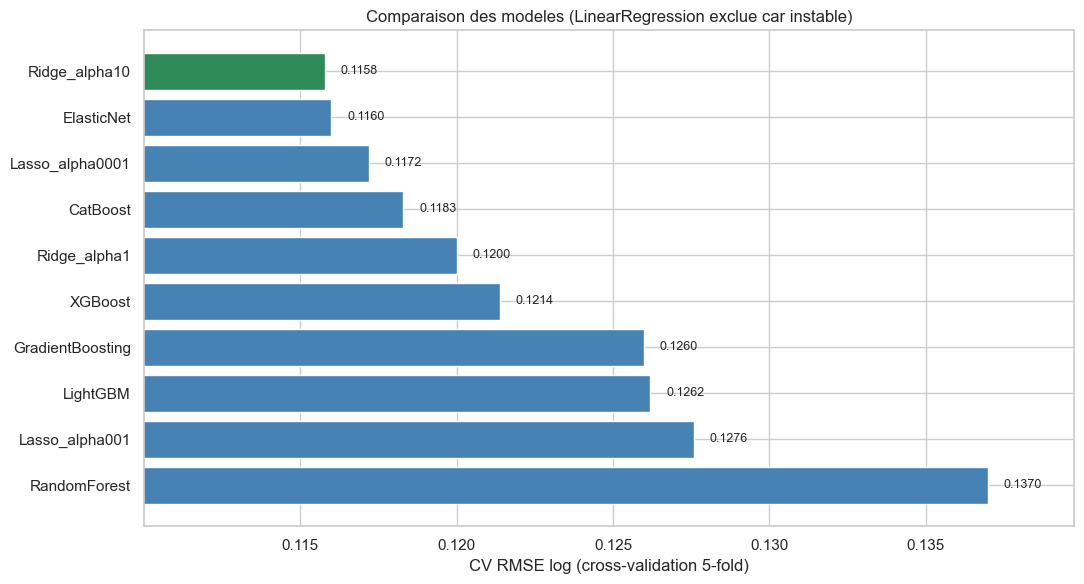

In [25]:
# Barplot horizontal des CV RMSE log : plus c'est bas, mieux c'est
# On exclut LinearRegression du graphe (CV RMSE de l'ordre de 250 millions, fausse l'echelle)
df_plot = df_resultats[df_resultats["modele"] != "LinearRegression"].sort_values("cv_rmse_log")

fig, ax = plt.subplots(figsize=(11, 6))
couleurs = ["seagreen" if i == 0 else "steelblue" for i in range(len(df_plot))]
ax.barh(df_plot["nom"], df_plot["cv_rmse_log"], color=couleurs)
ax.invert_yaxis()
ax.set_xlabel("CV RMSE log (cross-validation 5-fold)")
ax.set_title("Comparaison des modeles (LinearRegression exclue car instable)")
ax.set_xlim(df_plot["cv_rmse_log"].min() * 0.95, df_plot["cv_rmse_log"].max() * 1.02)

for i, valeur in enumerate(df_plot["cv_rmse_log"]):
    ax.text(valeur + 0.0005, i, f"{valeur:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

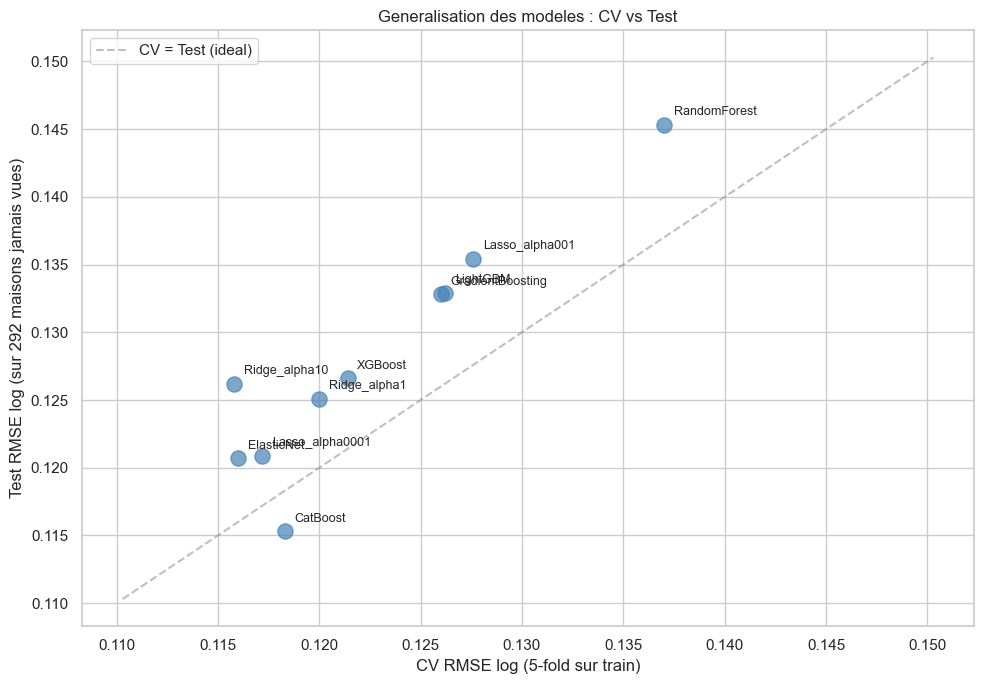

In [26]:
# CV RMSE vs Test RMSE : un modele bien generalise a CV proche du Test
df_plot = df_resultats[df_resultats["modele"] != "LinearRegression"]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df_plot["cv_rmse_log"], df_plot["test_rmse_log"], s=120, color="steelblue", alpha=0.7)

# Ligne diagonale ideale : CV == Test
lim_min = min(df_plot["cv_rmse_log"].min(), df_plot["test_rmse_log"].min()) - 0.005
lim_max = max(df_plot["cv_rmse_log"].max(), df_plot["test_rmse_log"].max()) + 0.005
ax.plot([lim_min, lim_max], [lim_min, lim_max], "--", color="gray", alpha=0.5, label="CV = Test (ideal)")

# Annotations
for _, ligne in df_plot.iterrows():
    ax.annotate(
        ligne["nom"], (ligne["cv_rmse_log"], ligne["test_rmse_log"]),
        xytext=(7, 7), textcoords="offset points", fontsize=9,
    )

ax.set_xlabel("CV RMSE log (5-fold sur train)")
ax.set_ylabel("Test RMSE log (sur 292 maisons jamais vues)")
ax.set_title("Generalisation des modeles : CV vs Test")
ax.legend()
plt.tight_layout()
plt.show()

### Observations

**Classement par CV RMSE log (la metrique de selection)** :

| Rang | Modele | CV RMSE log | Test R2 | RMSE $ |
|---|---|---|---|---|
| 1 | Ridge alpha=10 | **0.1158** | 0.9055 | 20 907 |
| 2 | ElasticNet | 0.1160 | 0.9136 | 20 274 |
| 3 | Lasso alpha=0.001 | 0.1172 | 0.9133 | 19 965 |
| 4 | **CatBoost** | 0.1183 | **0.9211** | **18 735** |
| 5 | Ridge alpha=1 | 0.1200 | 0.9071 | 21 510 |
| 6 | XGBoost | 0.1214 | 0.9049 | 20 485 |
| 7 | GradientBoosting | 0.1260 | 0.8953 | 20 663 |
| 8 | LightGBM | 0.1262 | 0.8953 | 20 774 |
| 9 | Lasso alpha=0.01 | 0.1276 | 0.8913 | 22 723 |
| 10 | RandomForest | 0.1370 | 0.8748 | 23 435 |
| 11 | LinearRegression | **250 M** | -0.34 | 447 337 |

**Insights** :

- **CatBoost est le meilleur sur le test** : Test RMSE log 0.1153, R2 0.9211, RMSE 18 735 $
- Les modeles lineaires regularises (Ridge, Lasso, ElasticNet) sont surprenamment competitifs (top 4-5 en CV), ce qui confirme que le feature engineering capture bien la structure lineaire des prix
- **LinearRegression sans regularisation est inutilisable** : CV RMSE de 250 millions, R2 negatif. Demontre concretement la necessite de la regularisation sur 252 features
- **RandomForest sous-performe** : avec 200 arbres et hyperparametres par defaut, il est domine par tous les boostings et meme par les modeles lineaires
- Le scatter **CV vs Test** montre que la plupart des modeles ont une legere degradation sur le test (overfit leger), sauf CatBoost qui est meme MEILLEUR sur le test que sur le CV

## 8. Selection du modele final

Le critere principal de selection est le **CV RMSE log** (estimation robuste) et le **Test RMSE log** (validation sur des donnees jamais vues).

**Modele retenu : `CatBoost`**

| Critere | Valeur |
|---|---|
| CV RMSE log | 0.1183 |
| Test RMSE log | 0.1153 |
| Test R2 | 0.9211 |
| Test RMSE dollars | 18 735 \$ |
| Test MAE dollars | 13 639 \$ |

**Justification du choix** :

1. Meilleur sur toutes les metriques de test (RMSE log, R2, RMSE dollars, MAE)
2. Stable : ecart CV/test minimal (0.1183 vers 0.1153), pas d'overfit
3. Le modele explique 92.1% de la variance du prix et produit une erreur typique de 13 639 dollars sur des prix allant de 35 000 a 755 000 dollars